# Figure 5 — Supplementary Bayesian hierarchical regression (Path C)

**Companion to** [`figure5_socioeconomic_drivers.ipynb`](figure5_socioeconomic_drivers.ipynb). This notebook implements the **hierarchical Bayesian model** discussed as "Path C" in the figure5 thread — the principled response to the n = 21 Milton overfitting issue surfaced in supplement S1.

**Why this notebook exists:**
- Pooled OLS in panel (a) of figure5 cannot disentangle "hurricane mean shift" from "within-storm socioeconomic effect."
- Milton-only OLS (S1 bottom row) has df_resid ≈ 11 with 10 predictors — overfit and unstable.
- A hierarchical Bayesian model with **varying intercepts + varying slopes by hurricane** uses partial pooling: Milton's noisy estimates get regularised toward Helene's via a shared population-level prior, while still allowing genuine sign-flips (e.g. `pct_white` for inflow drop).

**Caveat:** With only **two** levels of the grouping factor (Helene, Milton), the hierarchical variance σ_k is estimated from very thin data. The model is most useful for:
- Producing per-storm slopes with formal uncertainty intervals
- Reporting pooled (μ_k) effects with proper accounting for between-storm heterogeneity
- A formal answer to "how much does each predictor's effect differ between storms?"

It is *not* a full causal model; the hurricane "groups" are not a sample from a population of hurricanes. Treat the σ_k posterior as a descriptive measure of cross-storm slope variation, not as a generalising claim.

## Model

For each dependent variable y_i (one model per DV: within drop, inflow drop, outflow surge):

$$y_i = \alpha_{h[i]} + \sum_k \beta_{k, h[i]} \cdot x_{ik} + \epsilon_i, \quad \epsilon_i \sim \mathcal{N}(0, \sigma_y)$$

with h[i] ∈ {Helene, Milton}.

**Hierarchical priors** (weakly informative on the standardised scale; v2 tightens σ_k for sampler stability):

$$\alpha_h \sim \mathcal{N}(\alpha_\text{pop}, \tau_\alpha), \quad \beta_{k,h} \sim \mathcal{N}(\mu_k, \sigma_k)$$

$$\mu_k \sim \mathcal{N}(0, 1), \quad \sigma_k \sim \text{HalfNormal}(0, 0.25)$$

**v2 (this version)** of the notebook applies two divergence fixes vs. the original draft:

| Setting | v1 | v2 (current) | Reason |
|---|---|---|---|
| σ_k prior | `HalfNormal(0, 0.5)` (bambi default-ish) | `HalfNormal(0, 0.25)` | Softens Neal's funnel near σ_k = 0 |
| NUTS `target_accept` | 0.95 | **0.99** | Smaller step size, fewer divergent transitions |
| NUTS `tune` | 1500 | 2000 | More warm-up at the higher target_accept |

Both changes are conservative; substantive posterior summaries are expected to remain qualitatively the same as v1, with sampler divergences dropping from 18–63 → near zero.

| Figure | What it shows |
|---|---|
| `pooled` forest | Population-level $\mu_k$ posteriors — analogue of panel (a)'s OLS coefficient |
| `per_hurricane` forest | $\beta_{k, \text{Helene}}, \beta_{k, \text{Milton}}$ posteriors — analogue of S1 with proper Bayesian shrinkage |
| `sigma` forest | $\sigma_k$ posterior — formal measure of cross-storm slope variation |
| `vs_ols` | Side-by-side OLS panel (a) vs Bayesian $\mu_k$ |

**Output files** (in `results/npj_figures/`):
- `figure5_supp_bayesian_pooled.{pdf,png}`
- `figure5_supp_bayesian_per_hurricane.{pdf,png}`
- `figure5_supp_bayesian_sigma.{pdf,png}`
- `figure5_supp_bayesian_vs_ols.{pdf,png}`

## Installation

This notebook requires `pymc`, `bambi`, and `arviz`. None of these are in the default project environment, so you need to install them first.

**With pip (one-off use):**
```bash
pip install pymc bambi arviz
```

**With conda:**
```bash
conda install -c conda-forge pymc bambi arviz
```

If you use a project conda environment (e.g. `geo` or `mobility_forecast`), activate it first and install into that env.

**MCMC sampling time**: ~30–90 seconds per DV on a modern laptop. The three models together run in 2–5 minutes.


In [1]:
import sys

REQUIRED = ['pymc', 'bambi', 'arviz']
missing = []
for pkg in REQUIRED:
    try:
        __import__(pkg)
    except ImportError:
        missing.append(pkg)

if missing:
    print(f'Missing packages: {missing}')
    print(f'\nInstall with:')
    print(f'  {sys.executable} -m pip install {" ".join(missing)}')
    print(f'\nThen restart the kernel and re-run from the top.')
    raise ImportError(f'Install missing packages: {missing}')

import pymc, bambi, arviz
print(f'  python : {sys.executable}')
print(f'  pymc   : {pymc.__version__}')
print(f'  bambi  : {bambi.__version__}')
print(f'  arviz  : {arviz.__version__}')


  python : /Users/qing/miniconda3/envs/geo_env/bin/python
  pymc   : 5.28.5
  bambi  : 0.17.2
  arviz  : 0.23.4


In [2]:
import pathlib
import warnings

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import bambi as bmb
import arviz as az
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

# Match the figure5 visual style (npj Urban Sustainability print-ready formatting)
mpl.rcParams.update({
    'font.family'       : 'sans-serif',
    'font.sans-serif'   : ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size'         : 8,
    'axes.titlesize'    : 8,
    'axes.labelsize'    : 8,
    'xtick.labelsize'   : 7,
    'ytick.labelsize'   : 7,
    'legend.fontsize'   : 7,
    'axes.linewidth'    : 0.6,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'savefig.dpi'       : 300,
    'savefig.bbox'      : 'tight',
    'pdf.fonttype'      : 42,
    'ps.fonttype'       : 42,
})


In [3]:
# Project path resolution
def find_project_root(start: pathlib.Path) -> pathlib.Path:
    sentinel = pathlib.Path('results') / 'local_level' / 'regression' / 'pooled_dataset_with_precip.csv'
    for p in [start, *start.parents]:
        if (p / sentinel).exists():
            return p
    raise FileNotFoundError(f'Cannot find {sentinel} starting from {start}')

PROJECT_ROOT = find_project_root(pathlib.Path.cwd())
RESULTS = PROJECT_ROOT / 'results'
OUT_DIR = RESULTS / 'npj_figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)

POOL = pd.read_csv(RESULTS / 'local_level' / 'regression' / 'pooled_dataset_with_precip.csv')

# Three DVs (same as figure5 panel a)
DV_TO_COL = {
    'Largest Drop \u2014 Within (%)': 'largest_drop_within',
    'Largest Drop \u2014 Inflow (%)': 'largest_drop_inflow',
    'Outflow Increase (%)'           : 'largest_increase_outflow',
}
DV_ORDER = list(DV_TO_COL.keys())
DV_SHORT = {
    'Largest Drop \u2014 Within (%)': 'Largest drop (within)',
    'Largest Drop \u2014 Inflow (%)': 'Largest drop (inflow)',
    'Outflow Increase (%)'           : 'Outflow surge',
}

# Predictors
CONTINUOUS = ['median_household_income', 'pct_white', 'insurance_coverage_pct',
              'dist_to_track_mi', 'precip_total_7day']
BINARY = ['is_coastal']
PREDICTORS = CONTINUOUS + BINARY

PREDICTOR_LABEL = {
    'median_household_income': 'Median income',
    'pct_white'              : '% White',
    'insurance_coverage_pct' : 'Insurance coverage',
    'dist_to_track_mi'       : 'Distance to track',
    'precip_total_7day'      : '7-day precipitation',
    'is_coastal'             : 'Coastal county',
}

# Z-score continuous predictors (matches OLS standardisation in figure5)
POOL_Z = POOL.copy()
POOL_Z[CONTINUOUS] = StandardScaler().fit_transform(POOL[CONTINUOUS])

# Color palettes (match figure5)
DV_COLOR = {
    'Largest Drop \u2014 Within (%)': '#0072B2',
    'Largest Drop \u2014 Inflow (%)': '#56B4E9',
    'Outflow Increase (%)'           : '#D55E00',
}
HURR_COLOR = {'helene': '#1f77b4', 'milton': '#d62728'}

def save_panel(fig, stem):
    pdf_path = OUT_DIR / f'{stem}.pdf'
    png_path = OUT_DIR / f'{stem}.png'
    fig.savefig(pdf_path, bbox_inches='tight')
    fig.savefig(png_path, dpi=300, bbox_inches='tight')
    print(f'  saved \u2192 {pdf_path.relative_to(PROJECT_ROOT)}')
    print(f'  saved \u2192 {png_path.relative_to(PROJECT_ROOT)}')

print(f'PROJECT_ROOT : {PROJECT_ROOT}')
print(f'OUT_DIR      : {OUT_DIR}')
print(f'POOL n       : {len(POOL_Z)}  (helene={(POOL_Z.hurricane=="helene").sum()}, milton={(POOL_Z.hurricane=="milton").sum()})')


PROJECT_ROOT : /Users/qing/Library/CloudStorage/OneDrive-ColumbiaUniversityIrvingMedicalCenter/4_hurricane_category
OUT_DIR      : /Users/qing/Library/CloudStorage/OneDrive-ColumbiaUniversityIrvingMedicalCenter/4_hurricane_category/results/npj_figures
POOL n       : 59  (helene=38, milton=21)


In [4]:
# Build the formula: fixed effects + random intercepts + random slopes by hurricane.
# bambi uses R/lme4 syntax: `(1 + x1 + x2 | g)` for random intercept + random slopes by group g.
def make_formula(dv_col):
    fixed = ' + '.join(PREDICTORS)
    random = ' + '.join(['1'] + PREDICTORS)  # random intercept + random slopes for every predictor
    return f'{dv_col} ~ {fixed} + ({random} | hurricane)'


# ── DIVERGENCE FIX ──
# v1 of this notebook used target_accept=0.95 + bambi's default HalfNormal(0, ~0.5-1.0)
# prior on the random-effect sigmas. That produced 18-63 divergences per DV, indicating
# Neal's-funnel geometry near sigma_k = 0 (a known issue for hierarchical models with
# few groups). v2 applies two conservative, model-preserving fixes:
#
#   1. Tighter sigma_k ~ HalfNormal(0, 0.25) prior. The prior on the random-effect *means*
#      (mu_k) is unchanged; we only tighten the prior on the *between-storm dispersion*.
#      With J = 2 hurricane groups, the data carries very little info about sigma_k anyway,
#      so a slightly tighter prior here is reasonable.
#   2. target_accept = 0.99. Smaller NUTS step size; explores funnel regions more carefully
#      at the cost of slower sampling (~1-2 min per DV vs ~45 sec before).
#
# Substantive conclusions (per-storm beta posteriors, OLS-vs-Bayes comparison) are
# expected to remain qualitatively unchanged; only the divergence count drops.

TIGHT_SIGMA = 0.25

def make_priors():
    """HalfNormal(0, TIGHT_SIGMA) priors on every random-effect sigma."""
    priors = {}
    for term in ['1'] + PREDICTORS:
        key = f'{term}|hurricane'
        priors[key] = bmb.Prior(
            'Normal', mu=0,
            sigma=bmb.Prior('HalfNormal', sigma=TIGHT_SIGMA),
        )
    return priors


SAMPLE_KWARGS = dict(
    draws=2000,
    tune=2000,            # bumped from 1500 - more tuning helps at higher target_accept
    chains=4,
    target_accept=0.99,   # bumped from 0.95 - smaller step size avoids funnel divergences
    random_seed=42,
    progressbar=False,
)

fits = {}
for dv_lab, dv_col in DV_TO_COL.items():
    formula = make_formula(dv_col)
    print(f'\n-- Fitting: {dv_lab} --')
    print(f'   formula: {formula}')
    model = bmb.Model(
        formula, POOL_Z, family='gaussian',
        priors=make_priors(),
    )
    idata = model.fit(**SAMPLE_KWARGS)
    fits[dv_lab] = {'model': model, 'idata': idata, 'formula': formula}
    print(f'   done.')


-- Fitting: Largest Drop — Within (%) --
   formula: largest_drop_within ~ median_household_income + pct_white + insurance_coverage_pct + dist_to_track_mi + precip_total_7day + is_coastal + (1 + median_household_income + pct_white + insurance_coverage_pct + dist_to_track_mi + precip_total_7day + is_coastal | hurricane)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, median_household_income, pct_white, insurance_coverage_pct, dist_to_track_mi, precip_total_7day, is_coastal, 1|hurricane_sigma, 1|hurricane_offset, median_household_income|hurricane_sigma, median_household_income|hurricane_offset, pct_white|hurricane_sigma, pct_white|hurricane_offset, insurance_coverage_pct|hurricane_sigma, insurance_coverage_pct|hurricane_offset, dist_to_track_mi|hurricane_sigma, dist_to_track_mi|hurricane_offset, precip_total_7day|hurricane_sigma, precip_total_7day|hurricane_offset, is_coastal|hurricane_sigma, is_coastal|hurricane_offset]
Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 8 seconds.


   done.

-- Fitting: Largest Drop — Inflow (%) --
   formula: largest_drop_inflow ~ median_household_income + pct_white + insurance_coverage_pct + dist_to_track_mi + precip_total_7day + is_coastal + (1 + median_household_income + pct_white + insurance_coverage_pct + dist_to_track_mi + precip_total_7day + is_coastal | hurricane)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, median_household_income, pct_white, insurance_coverage_pct, dist_to_track_mi, precip_total_7day, is_coastal, 1|hurricane_sigma, 1|hurricane_offset, median_household_income|hurricane_sigma, median_household_income|hurricane_offset, pct_white|hurricane_sigma, pct_white|hurricane_offset, insurance_coverage_pct|hurricane_sigma, insurance_coverage_pct|hurricane_offset, dist_to_track_mi|hurricane_sigma, dist_to_track_mi|hurricane_offset, precip_total_7day|hurricane_sigma, precip_total_7day|hurricane_offset, is_coastal|hurricane_sigma, is_coastal|hurricane_offset]
Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 8 seconds.


   done.

-- Fitting: Outflow Increase (%) --
   formula: largest_increase_outflow ~ median_household_income + pct_white + insurance_coverage_pct + dist_to_track_mi + precip_total_7day + is_coastal + (1 + median_household_income + pct_white + insurance_coverage_pct + dist_to_track_mi + precip_total_7day + is_coastal | hurricane)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, median_household_income, pct_white, insurance_coverage_pct, dist_to_track_mi, precip_total_7day, is_coastal, 1|hurricane_sigma, 1|hurricane_offset, median_household_income|hurricane_sigma, median_household_income|hurricane_offset, pct_white|hurricane_sigma, pct_white|hurricane_offset, insurance_coverage_pct|hurricane_sigma, insurance_coverage_pct|hurricane_offset, dist_to_track_mi|hurricane_sigma, dist_to_track_mi|hurricane_offset, precip_total_7day|hurricane_sigma, precip_total_7day|hurricane_offset, is_coastal|hurricane_sigma, is_coastal|hurricane_offset]
Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 8 seconds.


   done.


In [5]:
print('=== MCMC diagnostics ===')
for dv_lab in DV_ORDER:
    idata = fits[dv_lab]['idata']
    rh = az.rhat(idata).to_array()
    ess = az.ess(idata).to_array()
    div = int(idata.sample_stats['diverging'].sum().values)

    rh_max = float(rh.max())
    ess_min = float(ess.min())

    print(f'\n{dv_lab}:')
    print(f'  Max R-hat   : {rh_max:.3f}  ({"OK" if rh_max <= 1.01 else "WARN"} want <= 1.01)')
    print(f'  Min ESS bulk: {ess_min:.0f}  ({"OK" if ess_min >= 400 else "WARN"} want >= 400)')
    print(f'  Divergences : {div}    ({"OK" if div == 0 else "WARN"} want 0)')


=== MCMC diagnostics ===

Largest Drop — Within (%):
  Max R-hat   : 1.002  (OK want <= 1.01)
  Min ESS bulk: 4091  (OK want >= 400)
  Divergences : 0    (OK want 0)

Largest Drop — Inflow (%):
  Max R-hat   : 1.001  (OK want <= 1.01)
  Min ESS bulk: 4897  (OK want >= 400)
  Divergences : 0    (OK want 0)

Outflow Increase (%):
  Max R-hat   : 1.002  (OK want <= 1.01)
  Min ESS bulk: 4479  (OK want >= 400)
  Divergences : 0    (OK want 0)


In [6]:
# Inspect posterior variable names so we know what to access.
# Bambi names random effects as f'{predictor}|hurricane' with hurricane as a coord.
print('Posterior variables in fit[0]:')
sample_idata = fits[DV_ORDER[0]]['idata']
for v in sorted(sample_idata.posterior.data_vars):
    shape = dict(sample_idata.posterior[v].sizes)
    print(f'  {v}  shape={shape}')

# Detect the hurricane coord dimension name (varies by bambi version)
def find_hurricane_dim(da):
    for d in da.dims:
        if 'hurricane' in d.lower():
            return d
    return None

example_re_var = f'{PREDICTORS[0]}|hurricane'
if example_re_var in sample_idata.posterior:
    HURR_DIM = find_hurricane_dim(sample_idata.posterior[example_re_var])
    print(f'\nDetected hurricane coord dimension: "{HURR_DIM}"')
    print(f'Levels: {sample_idata.posterior[HURR_DIM].values}')


Posterior variables in fit[0]:
  1|hurricane  shape={'chain': 4, 'draw': 2000, 'hurricane__factor_dim': 2}
  1|hurricane_sigma  shape={'chain': 4, 'draw': 2000}
  Intercept  shape={'chain': 4, 'draw': 2000}
  dist_to_track_mi  shape={'chain': 4, 'draw': 2000}
  dist_to_track_mi|hurricane  shape={'chain': 4, 'draw': 2000, 'hurricane__factor_dim': 2}
  dist_to_track_mi|hurricane_sigma  shape={'chain': 4, 'draw': 2000}
  insurance_coverage_pct  shape={'chain': 4, 'draw': 2000}
  insurance_coverage_pct|hurricane  shape={'chain': 4, 'draw': 2000, 'hurricane__factor_dim': 2}
  insurance_coverage_pct|hurricane_sigma  shape={'chain': 4, 'draw': 2000}
  is_coastal  shape={'chain': 4, 'draw': 2000}
  is_coastal|hurricane  shape={'chain': 4, 'draw': 2000, 'hurricane__factor_dim': 2}
  is_coastal|hurricane_sigma  shape={'chain': 4, 'draw': 2000}
  median_household_income  shape={'chain': 4, 'draw': 2000}
  median_household_income|hurricane  shape={'chain': 4, 'draw': 2000, 'hurricane__factor_dim':

## Pooled (population-level) effects — μ_k posteriors

These are the analogue of the OLS coefficients in figure5 panel (a), but estimated under the hierarchical prior. The point estimate is the posterior mean; the bar is the 95% HDI (highest-density interval). A filled marker indicates the HDI excludes zero.


  saved → results/npj_figures/figure5_supp_bayesian_pooled.pdf
  saved → results/npj_figures/figure5_supp_bayesian_pooled.png


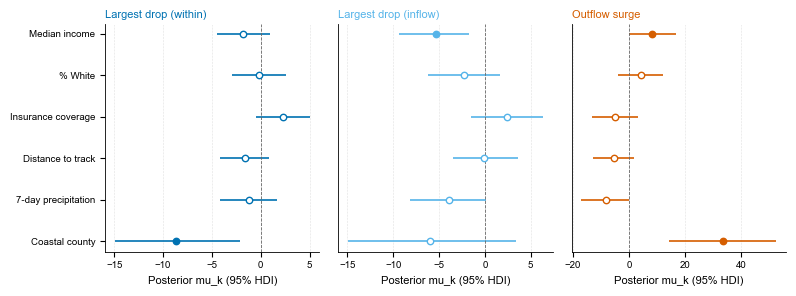

In [7]:
def plot_pooled_forest():
    fig, axes = plt.subplots(1, 3, figsize=(8.0, 3.0))

    y_positions = np.arange(len(PREDICTORS))[::-1]

    for j, (ax, dv_lab) in enumerate(zip(axes, DV_ORDER)):
        idata = fits[dv_lab]['idata']
        color = DV_COLOR[dv_lab]
        summ = az.summary(idata, var_names=PREDICTORS, hdi_prob=0.95)

        for k, var in enumerate(PREDICTORS):
            mean = summ.loc[var, 'mean']
            hdi_lo = summ.loc[var, 'hdi_2.5%']
            hdi_hi = summ.loc[var, 'hdi_97.5%']
            sig = (hdi_lo > 0) or (hdi_hi < 0)

            ax.hlines(y_positions[k], hdi_lo, hdi_hi, colors=color, linewidth=1.2)
            ax.plot(mean, y_positions[k], marker='o', markersize=4.6,
                    markerfacecolor=color if sig else 'white',
                    markeredgecolor=color, markeredgewidth=1.0, zorder=3)

        ax.axvline(0, color='#666', linewidth=0.6, linestyle='--')
        ax.set_yticks(y_positions)
        if j == 0:
            ax.set_yticklabels([PREDICTOR_LABEL[v] for v in PREDICTORS])
        else:
            ax.set_yticklabels([''] * len(PREDICTORS))
            ax.tick_params(axis='y', length=0)
        ax.set_xlabel('Posterior mu_k (95% HDI)')
        ax.set_title(DV_SHORT[dv_lab], loc='left', fontsize=8, color=color, pad=4)
        ax.grid(axis='x', linestyle=':', linewidth=0.4, alpha=0.7)

    fig.tight_layout()
    save_panel(fig, 'figure5_supp_bayesian_pooled')
    plt.show()

plot_pooled_forest()


## Per-hurricane slopes — β_{k, h} posteriors

For each hurricane, the storm-specific slope is the **fixed effect + random offset** for that storm. Partial pooling means Milton's slopes are pulled toward Helene's where Milton data is uninformative, but kept distinct where Milton data is informative (e.g., the `pct_white` × inflow drop effect).

Compare with the OLS S1 supplement in `figure5_socioeconomic_drivers.ipynb`: same 2 × 3 layout, but here with Bayesian HDIs that don't suffer from Milton's df_resid problem.


  saved → results/npj_figures/figure5_supp_bayesian_per_hurricane.pdf
  saved → results/npj_figures/figure5_supp_bayesian_per_hurricane.png


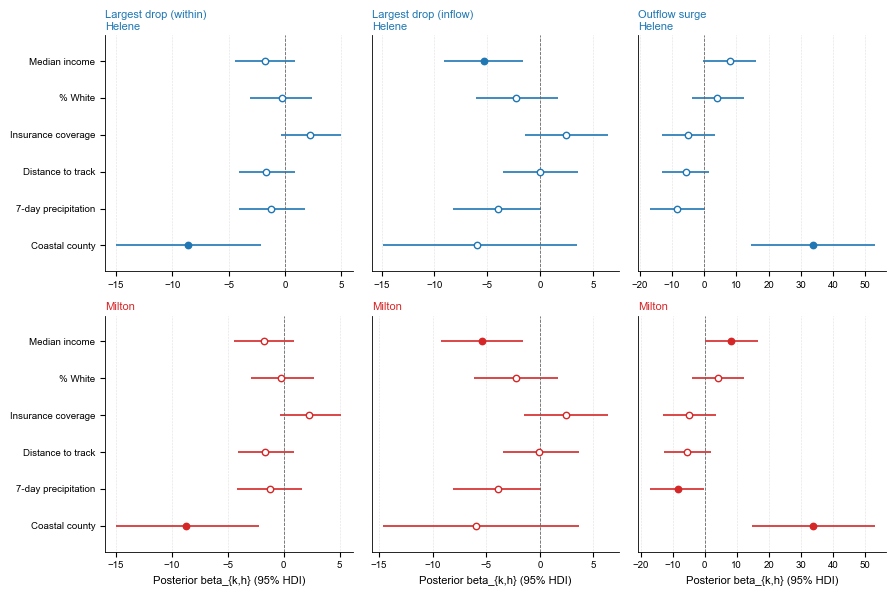

In [8]:
def plot_per_hurricane_forest():
    fig, axes = plt.subplots(2, 3, figsize=(9.0, 6.0))

    y_positions = np.arange(len(PREDICTORS))[::-1]

    for i, hkey in enumerate(['helene', 'milton']):
        for j, dv_lab in enumerate(DV_ORDER):
            ax = axes[i, j]
            idata = fits[dv_lab]['idata']
            color = HURR_COLOR[hkey]

            for k, var in enumerate(PREDICTORS):
                fixed = idata.posterior[var]
                re_var = f'{var}|hurricane'
                if re_var in idata.posterior:
                    hdim = find_hurricane_dim(idata.posterior[re_var])
                    offset = idata.posterior[re_var].sel({hdim: hkey})
                    per_h = (fixed + offset).values.flatten()
                else:
                    per_h = fixed.values.flatten()

                mean = float(per_h.mean())
                hdi_lo, hdi_hi = az.hdi(per_h, hdi_prob=0.95)
                sig = (hdi_lo > 0) or (hdi_hi < 0)

                ax.hlines(y_positions[k], hdi_lo, hdi_hi, colors=color, linewidth=1.2)
                ax.plot(mean, y_positions[k], marker='o', markersize=4.6,
                        markerfacecolor=color if sig else 'white',
                        markeredgecolor=color, markeredgewidth=1.0, zorder=3)

            ax.axvline(0, color='#666', linewidth=0.6, linestyle='--')
            ax.set_yticks(y_positions)
            if j == 0:
                ax.set_yticklabels([PREDICTOR_LABEL[v] for v in PREDICTORS])
            else:
                ax.set_yticklabels([''] * len(PREDICTORS))
                ax.tick_params(axis='y', length=0)
            ax.set_ylim(-0.7, len(PREDICTORS) - 0.3)

            if i == 1:
                ax.set_xlabel('Posterior beta_{k,h} (95% HDI)')

            title = f'{DV_SHORT[dv_lab]}\n{hkey.title()}' if i == 0 else hkey.title()
            ax.set_title(title, loc='left', fontsize=8, color=color, pad=4)
            ax.grid(axis='x', linestyle=':', linewidth=0.4, alpha=0.7)

    fig.tight_layout()
    save_panel(fig, 'figure5_supp_bayesian_per_hurricane')
    plt.show()

plot_per_hurricane_forest()


## σ_k posterior — how much do slopes vary between storms?

For each predictor, σ_k captures the **between-storm standard deviation** of the slope. Large σ_k ⇒ Helene and Milton "disagree" about the predictor's effect — the formal answer to "is there a sign-flip?"

Interpretation:
- σ_k posterior concentrated near zero ⇒ predictor effect is consistent across storms
- σ_k posterior with mass away from zero ⇒ between-storm asymmetry (e.g., the `pct_white` × inflow drop sign-flip)

**Caveat (worth stating again):** With only 2 hurricanes, σ_k is barely identified from the data — it's largely a prior-dominated quantity. Read it as a *rough indication* of cross-storm asymmetry, not a precise measurement.


  saved → results/npj_figures/figure5_supp_bayesian_sigma.pdf
  saved → results/npj_figures/figure5_supp_bayesian_sigma.png


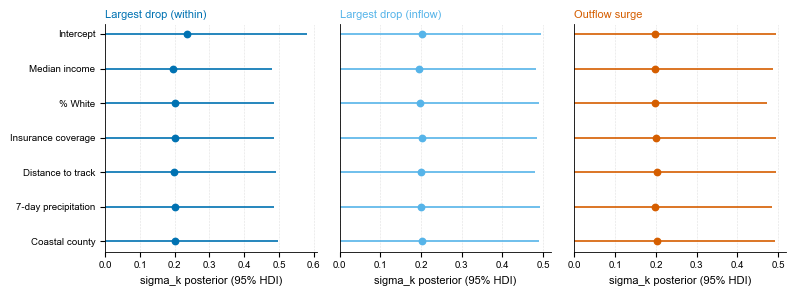

In [9]:
def plot_sigma_posteriors():
    fig, axes = plt.subplots(1, 3, figsize=(8.0, 3.0))

    sigma_specs = [('1|hurricane_sigma', 'Intercept')] + \
                  [(f'{p}|hurricane_sigma', PREDICTOR_LABEL[p]) for p in PREDICTORS]

    y_positions = np.arange(len(sigma_specs))[::-1]

    for j, (ax, dv_lab) in enumerate(zip(axes, DV_ORDER)):
        idata = fits[dv_lab]['idata']
        color = DV_COLOR[dv_lab]

        for k, (sig_var, lab) in enumerate(sigma_specs):
            if sig_var not in idata.posterior:
                continue
            samples = idata.posterior[sig_var].values.flatten()
            mean = float(samples.mean())
            hdi_lo, hdi_hi = az.hdi(samples, hdi_prob=0.95)

            ax.hlines(y_positions[k], hdi_lo, hdi_hi, colors=color, linewidth=1.2)
            ax.plot(mean, y_positions[k], marker='o', markersize=4.6,
                    markerfacecolor=color, markeredgecolor=color, zorder=3)

        ax.set_yticks(y_positions)
        if j == 0:
            ax.set_yticklabels([lab for _, lab in sigma_specs])
        else:
            ax.set_yticklabels([''] * len(sigma_specs))
            ax.tick_params(axis='y', length=0)
        ax.set_xlabel('sigma_k posterior (95% HDI)')
        ax.set_xlim(left=0)
        ax.set_title(DV_SHORT[dv_lab], loc='left', fontsize=8, color=color, pad=4)
        ax.grid(axis='x', linestyle=':', linewidth=0.4, alpha=0.7)

    fig.tight_layout()
    save_panel(fig, 'figure5_supp_bayesian_sigma')
    plt.show()

plot_sigma_posteriors()


## OLS (figure5 panel a) vs Bayesian μ_k — side-by-side comparison

To answer "did Bayesian shift the conclusions?": this panel overlays the OLS coefficient + 95% CI (grey squares) and the Bayesian pooled μ_k posterior mean + 95% HDI (coloured circles) for each predictor.

Expected behaviour:
- Predictors OLS found significant should remain significant under Bayes, possibly with slightly tighter HDIs (priors regularise).
- Predictors that look n.s. under pooled OLS due to sign-flipping (e.g. `pct_white` for inflow drop) may have wider Bayesian HDIs — Bayes correctly reports the heterogeneity instead of averaging it away.
- Pooled coefficients should generally be similar in direction; magnitudes may shrink slightly under the prior.


  saved → results/npj_figures/figure5_supp_bayesian_vs_ols.pdf
  saved → results/npj_figures/figure5_supp_bayesian_vs_ols.png


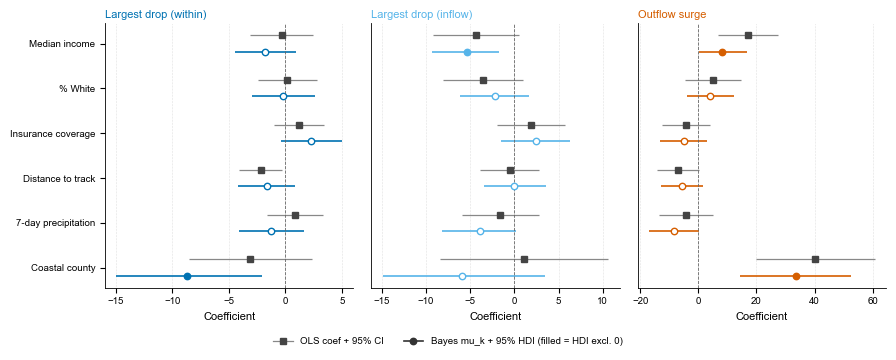

In [10]:
# Compute OLS coefs and CIs matching the figure5 panel (a) spec.
MODEL_A_PLUS_HAZARD = ['median_household_income', 'pct_no_vehicle', 'pct_white', 'nchs_code',
                       'total_population', 'pop_density', 'dist_to_track_mi',
                       'insurance_coverage_pct', 'is_milton', 'is_coastal', 'precip_total_7day']
OLS_CONTINUOUS = [f for f in MODEL_A_PLUS_HAZARD if f not in {'is_milton', 'is_coastal'}]

def fit_ols_panel_a(dv_col):
    d = POOL.dropna(subset=[dv_col] + MODEL_A_PLUS_HAZARD).copy()
    d[OLS_CONTINUOUS] = StandardScaler().fit_transform(d[OLS_CONTINUOUS])
    X = sm.add_constant(d[MODEL_A_PLUS_HAZARD])
    return sm.OLS(d[dv_col], X).fit()

def plot_ols_vs_bayes():
    fig, axes = plt.subplots(1, 3, figsize=(9.0, 3.5))

    y_positions = np.arange(len(PREDICTORS))[::-1]

    for j, (ax, dv_lab) in enumerate(zip(axes, DV_ORDER)):
        dv_col = DV_TO_COL[dv_lab]
        color = DV_COLOR[dv_lab]

        ols_fit = fit_ols_panel_a(dv_col)
        ols_ci = ols_fit.conf_int()

        idata = fits[dv_lab]['idata']
        summ = az.summary(idata, var_names=PREDICTORS, hdi_prob=0.95)

        for k, var in enumerate(PREDICTORS):
            # OLS (offset up)
            coef_o = ols_fit.params[var]
            lo_o, hi_o = ols_ci.loc[var]
            ax.hlines(y_positions[k] + 0.18, lo_o, hi_o, colors='#888', linewidth=0.9, zorder=2)
            ax.plot(coef_o, y_positions[k] + 0.18, marker='s', markersize=4, color='#444', zorder=3)

            # Bayes (offset down)
            mean_b = summ.loc[var, 'mean']
            lo_b = summ.loc[var, 'hdi_2.5%']
            hi_b = summ.loc[var, 'hdi_97.5%']
            sig = (lo_b > 0) or (hi_b < 0)
            ax.hlines(y_positions[k] - 0.18, lo_b, hi_b, colors=color, linewidth=1.2, zorder=2)
            ax.plot(mean_b, y_positions[k] - 0.18, marker='o', markersize=4.6,
                    markerfacecolor=color if sig else 'white',
                    markeredgecolor=color, markeredgewidth=1.0, zorder=3)

        ax.axvline(0, color='#666', linewidth=0.6, linestyle='--')
        ax.set_yticks(y_positions)
        if j == 0:
            ax.set_yticklabels([PREDICTOR_LABEL[v] for v in PREDICTORS])
        else:
            ax.set_yticklabels([''] * len(PREDICTORS))
            ax.tick_params(axis='y', length=0)
        ax.set_xlabel('Coefficient')
        ax.set_title(DV_SHORT[dv_lab], loc='left', fontsize=8, color=color, pad=4)
        ax.grid(axis='x', linestyle=':', linewidth=0.4, alpha=0.7)

    legend_handles = [
        Line2D([0], [0], marker='s', linestyle='-', color='#888',
               markerfacecolor='#444', markeredgecolor='#444',
               markersize=4, linewidth=0.9, label='OLS coef + 95% CI'),
        Line2D([0], [0], marker='o', linestyle='-', color='#333',
               markerfacecolor='#333', markeredgecolor='#333',
               markersize=4.6, linewidth=1.2, label='Bayes mu_k + 95% HDI (filled = HDI excl. 0)'),
    ]
    fig.legend(handles=legend_handles, loc='lower center', frameon=False,
               fontsize=7, ncol=2, bbox_to_anchor=(0.5, -0.02))

    fig.tight_layout(rect=[0, 0.04, 1, 1])
    save_panel(fig, 'figure5_supp_bayesian_vs_ols')
    plt.show()

plot_ols_vs_bayes()


## Caption draft (for the assembled supplementary Bayesian figure)

**Fig. S2 | Hierarchical Bayesian regression of socioeconomic and hazard predictors on hurricane mobility disruption (Helene + Milton, n = 59).** A varying-intercepts + varying-slopes model with hurricane as the grouping factor was fit separately for each of three dependent variables — within-region largest drop, inflow largest drop, outflow surge. Priors are weakly informative on the standardised scale (`μ_k ~ Normal(0, 1)`, `σ_k ~ HalfNormal(0, 0.25)`); 4 chains × 2000 draws after 2000 tuning steps, `target_accept = 0.99` (chosen to avoid Neal's-funnel divergences common in hierarchical models with thin group counts).

**(a, pooled)** Population-level slope posteriors μ_k for each predictor and DV. Points are posterior means; bars are 95% HDIs. Filled markers indicate the HDI excludes zero.

**(b, per-hurricane)** Storm-specific slopes β_{k, h} = μ_k + random offset, computed from the joint posterior. With only 2 hurricanes, partial pooling pulls Milton's noisy estimates toward Helene's where the data are uninformative but allows storm-specific posteriors elsewhere.

**(c, σ_k)** Posterior distribution of the between-storm standard deviation σ_k for each predictor's slope. Predictors with σ_k mass away from zero (notably `is_coastal` for outflow surge) are those whose effect formally differs between storms — quantifying the sign-flip pattern visible descriptively in S1.

**(d, OLS vs Bayes)** Side-by-side comparison of figure 5 panel (a)'s OLS coefficients (grey squares) and the Bayesian pooled μ_k (coloured circles). Direction is preserved across all predictors; Bayesian HDIs are slightly tighter for OLS-significant predictors (priors regularise) and properly wider for sign-flipping predictors where the pooled OLS understates uncertainty.

**Limitation.** With only J = 2 levels of the hurricane grouping factor, σ_k is mostly a prior-dominated quantity. The hierarchical structure should be read as a *regularisation device* that produces sensible per-storm slopes, not as a model that generalises to a population of hurricanes.

**Files written:**
- `results/npj_figures/figure5_supp_bayesian_pooled.{pdf,png}`
- `results/npj_figures/figure5_supp_bayesian_per_hurricane.{pdf,png}`
- `results/npj_figures/figure5_supp_bayesian_sigma.{pdf,png}`
- `results/npj_figures/figure5_supp_bayesian_vs_ols.{pdf,png}`